In [16]:
import pandas as pd

df = pd.read_csv("../data/processed/caba_apartments_clean.csv")

In [17]:
df.shape

(96735, 26)

## 1. Where is apartment supply concentrated in CABA?

In [52]:
base_df["l3"].value_counts()

l3
Palermo                 17651
Belgrano                10945
Almagro                  9162
Caballito                8510
Villa Crespo             7462
Recoleta                 6959
Villa Urquiza            4431
Barrio Norte             4405
Balvanera                3586
Flores                   3301
Nuñez                    3140
Colegiales               2484
Puerto Madero            2110
San Cristobal            2036
Saavedra                 1562
Villa Devoto             1496
Villa del Parque         1492
San Telmo                1405
San Nicolás              1368
Villa Luro               1276
Monserrat                1259
Parque Centenario        1212
Liniers                  1184
Boedo                    1180
Parque Chacabuco         1104
Retiro                   1083
Congreso                  995
Floresta                  991
Chacarita                 959
Once                      911
Barracas                  885
Coghlan                   806
Las Cañitas               791
Paterna

In [53]:
base_df["l3"].value_counts(normalize=True) * 100

l3
Palermo                 15.163699
Belgrano                 9.402679
Almagro                  7.870931
Caballito                7.310808
Villa Crespo             6.410488
Recoleta                 5.978368
Villa Urquiza            3.806603
Barrio Norte             3.784267
Balvanera                3.080677
Flores                   2.835838
Nuñez                    2.697525
Colegiales               2.133966
Puerto Madero            1.812668
San Cristobal            1.749096
Saavedra                 1.341890
Villa Devoto             1.285190
Villa del Parque         1.281754
San Telmo                1.207014
San Nicolás              1.175227
Villa Luro               1.096192
Monserrat                1.081587
Parque Centenario        1.041210
Liniers                  1.017156
Boedo                    1.013720
Parque Chacabuco         0.948429
Retiro                   0.930388
Congreso                 0.854789
Floresta                 0.851353
Chacarita                0.823862
Once       

In [19]:
df["l3"].value_counts(normalize=True) * 100

l3
Palermo                 16.376213
Belgrano                 9.081213
Almagro                  8.332557
Caballito                7.120002
Villa Crespo             6.800037
Recoleta                 6.358920
Barrio Norte             4.019757
Villa Urquiza            3.728785
Balvanera                2.815487
Nuñez                    2.719187
Flores                   2.599070
Colegiales               2.154847
Puerto Madero            1.814172
San Cristobal            1.341990
Villa del Parque         1.321280
San Telmo                1.277790
Villa Devoto             1.195986
Saavedra                 1.174241
Parque Centenario        1.168028
San Nicolás              1.135928
Monserrat                1.111077
Retiro                   0.987854
Parque Chacabuco         0.955754
Boedo                    0.913299
Once                     0.885341
Congreso                 0.878092
Barracas                 0.809750
Floresta                 0.805608
Liniers                  0.771437
Chacarita  

In [54]:
top_10_supply = base_df["l3"].value_counts().head(10)
top_10_supply

l3
Palermo          17651
Belgrano         10945
Almagro           9162
Caballito         8510
Villa Crespo      7462
Recoleta          6959
Villa Urquiza     4431
Barrio Norte      4405
Balvanera         3586
Flores            3301
Name: count, dtype: int64

<Axes: xlabel='l3'>

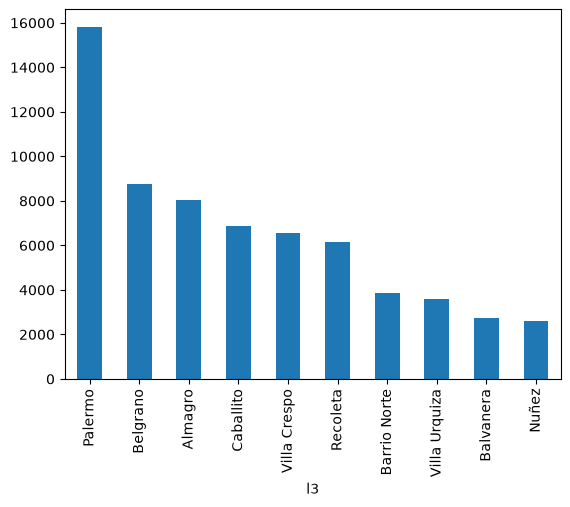

In [21]:
top_10_supply.plot(kind="bar")

<Axes: ylabel='l3'>

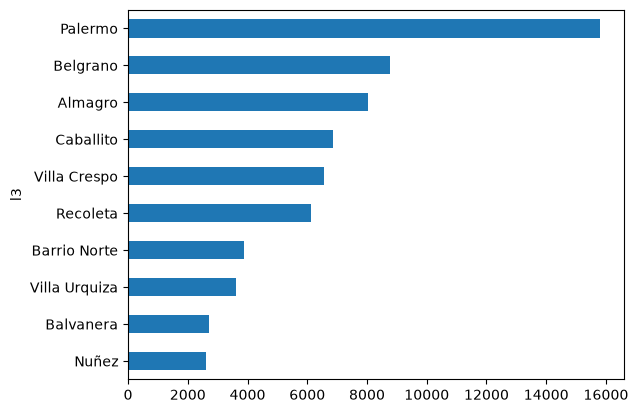

In [22]:
top_10_supply.sort_values().plot(kind="barh")

Text(0, 0.5, 'Neighborhood')

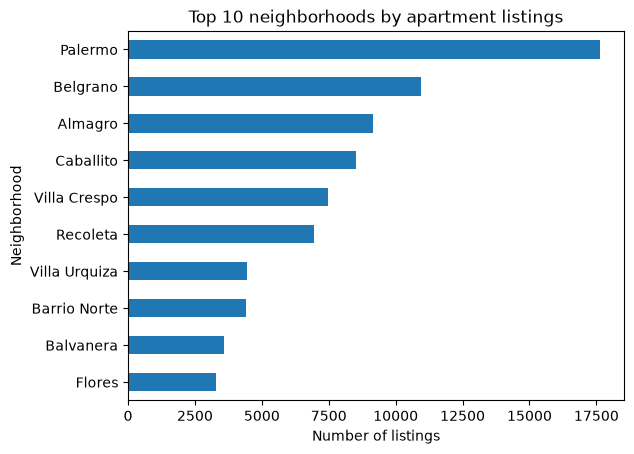

In [55]:
ax = top_10_supply.sort_values().plot(
    kind="barh",
    title="Top 10 neighborhoods by apartment listings"
)

ax.set_xlabel("Number of listings")
ax.set_ylabel("Neighborhood")

### Supply by neighborhood

Palermo has the highest concentration of apartment listings in the dataset, representing approximately 15.2% of the analyzed listings. Belgrano and Almagro follow with 9.1% and 8.3%, respectively.

This suggests that the available apartment supply in the dataset is particularly concentrated in Palermo.

## 2. How does price per m² vary by neighborhood?

In [24]:
df.groupby("l3")

In [25]:
df.groupby("l3")["price_per_m2"].median().sort_values(ascending=False)

l3
Puerto Madero           5765.306122
Las Cañitas             3571.428571
Palermo                 3263.888889
Belgrano                3222.222222
Recoleta                3194.444444
Nuñez                   3162.846591
Barrio Norte            3000.000000
Distrito Audiovisual    3000.000000
Coghlan                 2837.837838
Retiro                  2814.712644
Villa Urquiza           2804.347826
Saavedra                2666.666667
Villa Pueyrredón        2625.000000
Chacarita               2604.166667
Villa Ortuzar           2600.000000
Caballito               2585.199934
Villa Devoto            2583.333333
Colegiales              2564.516129
Almagro                 2466.666667
Villa Crespo            2460.526316
Villa del Parque        2431.970128
Agronomía               2420.706831
Villa Real              2387.455197
Parque Chas             2371.428571
Parque Centenario       2358.974359
Barracas                2342.105263
Paternal                2340.425532
San Telmo               2

In [26]:
neighborhood_stats = df.groupby("l3").agg(
    median_price_m2=("price_per_m2", "median"),
    listings=("price_per_m2", "count")
)

neighborhood_stats

,median_price_m2,listings
l3,,
Abasto,2297.297297,502
Agronomía,2420.706831,150
Almagro,2466.666667,8047
Balvanera,2073.170732,2719
Barracas,2342.105263,782
Barrio Norte,3000.000000,3882
Belgrano,3222.222222,8770
Boca,1670.068027,402
Boedo,2234.042553,882


In [27]:
reliable_neighborhoods = neighborhood_stats[
    neighborhood_stats["listings"] >= 100
]

In [28]:
reliable_neighborhoods["median_price_m2"].sort_values(ascending=False)

l3
Puerto Madero           5765.306122
Las Cañitas             3571.428571
Palermo                 3263.888889
Belgrano                3222.222222
Recoleta                3194.444444
Nuñez                   3162.846591
Barrio Norte            3000.000000
Coghlan                 2837.837838
Retiro                  2814.712644
Villa Urquiza           2804.347826
Saavedra                2666.666667
Villa Pueyrredón        2625.000000
Chacarita               2604.166667
Villa Ortuzar           2600.000000
Caballito               2585.199934
Villa Devoto            2583.333333
Colegiales              2564.516129
Almagro                 2466.666667
Villa Crespo            2460.526316
Villa del Parque        2431.970128
Agronomía               2420.706831
Parque Chas             2371.428571
Parque Centenario       2358.974359
Barracas                2342.105263
Paternal                2340.425532
San Telmo               2308.823529
Abasto                  2297.297297
Centro / Microcentro    2

In [29]:
top_10_price_m2 = reliable_neighborhoods["median_price_m2"].sort_values(
    ascending=False
).head(10)

In [30]:
top_10_price_m2


l3
Puerto Madero    5765.306122
Las Cañitas      3571.428571
Palermo          3263.888889
Belgrano         3222.222222
Recoleta         3194.444444
Nuñez            3162.846591
Barrio Norte     3000.000000
Coghlan          2837.837838
Retiro           2814.712644
Villa Urquiza    2804.347826
Name: median_price_m2, dtype: float64

<Axes: ylabel='l3'>

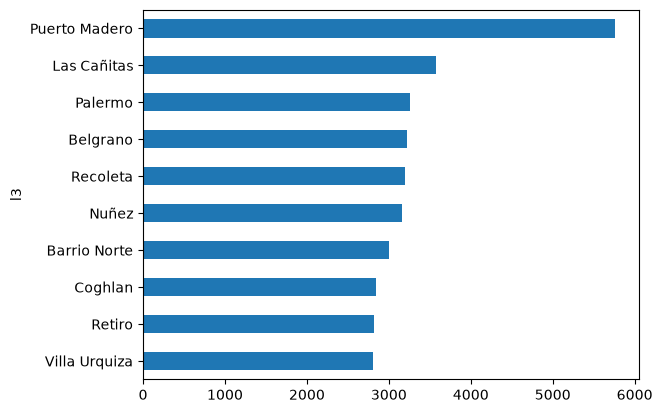

In [31]:
top_10_price_m2.sort_values().plot(kind="barh")

Text(0, 0.5, 'Neighborhood')

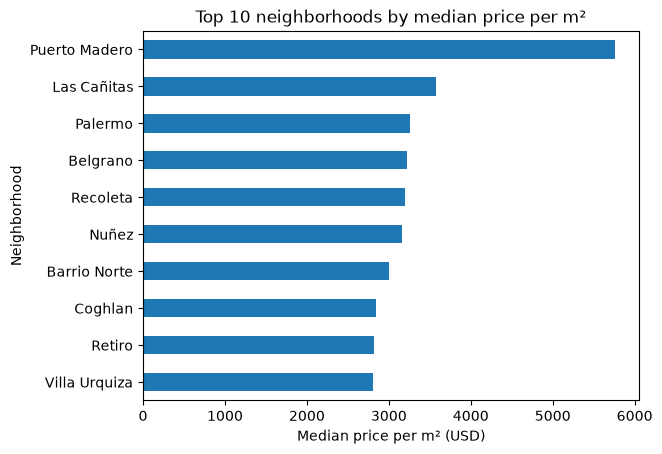

In [32]:
ax = top_10_price_m2.sort_values().plot(
    kind="barh",
    title="Top 10 neighborhoods by median price per m²"
)

ax.set_xlabel("Median price per m² (USD)")
ax.set_ylabel("Neighborhood")

### Conclusion

Puerto Madero has the highest median asking price per m² in the dataset, at approximately USD 5,765/m², substantially above the other analyzed neighborhoods.

Las Cañitas ranks second at approximately USD 3,571/m², followed by Palermo, Belgrano, Recoleta, and Núñez, all with median prices above USD 3,100/m².

Only neighborhoods with at least 100 listings were included in the comparison to avoid drawing conclusions from very small samples.

## 3. How does price per m² vary by number of rooms?

In [33]:
df["rooms"].value_counts().sort_index()

rooms
1.0     18410
2.0     27634
3.0     25785
4.0     15270
5.0      3573
6.0      1040
7.0       305
8.0       193
9.0        47
10.0       36
11.0        9
12.0       19
14.0        3
15.0        4
16.0        1
18.0        1
20.0        2
21.0        1
Name: count, dtype: int64

In [35]:
df["rooms"].isna().sum()

np.int64(4402)

In [36]:
df.groupby("rooms")["price_per_m2"].median()

rooms
1.0     2750.000000
2.0     2699.289474
3.0     2636.363636
4.0     2727.272727
5.0     2866.666667
6.0     3116.928957
7.0     3033.333333
8.0     2727.272727
9.0     2193.548387
10.0    2063.829787
11.0    1627.218935
12.0    2285.714286
14.0    3239.436620
15.0    1357.142857
16.0    1166.489926
18.0     621.761658
20.0    2536.058700
21.0    2547.169811
Name: price_per_m2, dtype: float64

In [37]:
room_stats = df.groupby("rooms").agg(
    median_price_m2=("price_per_m2", "median"),
    listings=("price_per_m2", "count")
)

In [38]:
room_stats

,median_price_m2,listings
rooms,,
1.0,2750.000000,18410
2.0,2699.289474,27634
3.0,2636.363636,25785
4.0,2727.272727,15270
5.0,2866.666667,3573
6.0,3116.928957,1040
7.0,3033.333333,305
8.0,2727.272727,193
9.0,2193.548387,47


In [39]:
reliable_room_stats = room_stats.loc[1:6]

Text(0, 0.5, 'Median asking price per m² (USD)')

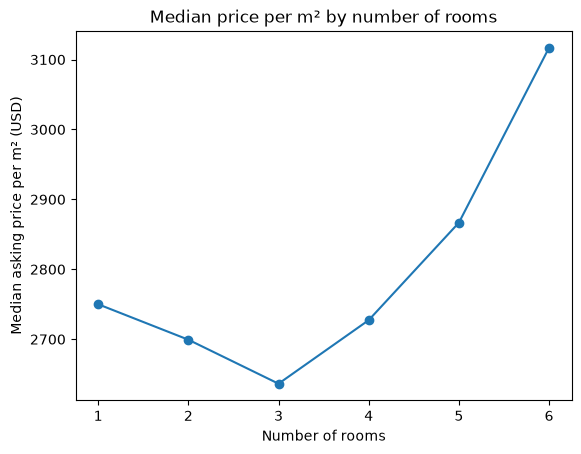

In [40]:
ax = reliable_room_stats["median_price_m2"].plot(
    kind="line",
    marker="o",
    title="Median price per m² by number of rooms"
)

ax.set_xlabel("Number of rooms")
ax.set_ylabel("Median asking price per m² (USD)")

### Conclusion

Median asking price per m² does not show a simple linear relationship with the number of rooms.

Among apartments with 1 to 6 rooms, the median price per m² decreases from 1-room to 3-room units, reaching its lowest point at approximately USD 2,636/m². It then increases for larger apartments, reaching approximately USD 3,117/m² for 6-room units.

This pattern may partly reflect differences in the neighborhoods where larger apartments are concentrated, so the number of rooms alone should not be interpreted as the cause of the higher price per m².

### 4. Does the relationship between rooms and price per m² remain within high-supply neighborhoods?

In [42]:
df["l3"].isin(["Palermo", "Belgrano", "Almagro", "Caballito", "Villa Crespo"])

0         True
1         True
2         True
3         True
4         True
         ...  
96730     True
96731    False
96732     True
96733     True
96734    False
Name: l3, Length: 96735, dtype: bool

In [43]:
df[["l3"]].head(20)

,l3
0,Palermo
1,Palermo
2,Palermo
3,Palermo
4,Palermo
5,Belgrano
6,Floresta
7,Recoleta
8,Recoleta
9,Barrio Norte


In [44]:
top_5_neighborhoods = df[
    df["l3"].isin(["Palermo", "Belgrano", "Almagro", "Caballito", "Villa Crespo"])
]

In [45]:
top_5_neighborhoods["l3"].value_counts()

l3
Palermo         15815
Belgrano         8770
Almagro          8047
Caballito        6876
Villa Crespo     6567
Name: count, dtype: int64

In [46]:
top_5_rooms = top_5_neighborhoods[
    top_5_neighborhoods["rooms"].isin([1, 2, 3])
]

In [47]:
top_5_rooms["rooms"].value_counts().sort_index()

rooms
1.0     8511
2.0    13324
3.0    12113
Name: count, dtype: int64

In [48]:
top_5_rooms.groupby(["l3", "rooms"])["price_per_m2"].median()

l3            rooms
Almagro       1.0      2674.285714
              2.0      2500.000000
              3.0      2462.686567
Belgrano      1.0      3278.461538
              2.0      3189.331437
              3.0      3217.115923
Caballito     1.0      2720.655738
              2.0      2583.333333
              3.0      2533.333333
Palermo       1.0      3289.473684
              2.0      3253.968254
              3.0      3152.173913
Villa Crespo  1.0      2658.536585
              2.0      2571.428571
              3.0      2365.079365
Name: price_per_m2, dtype: float64

### Additional analysis: rooms within high-supply neighborhoods

The higher price per m² observed for smaller apartments is not explained only by differences between neighborhoods.

Across the five neighborhoods with the highest number of listings, 1-room apartments consistently show the highest median asking price per m².

In four of the five neighborhoods, median price per m² decreases from 1-room to 3-room apartments. Belgrano is the only exception, where 3-room apartments have a slightly higher median price per m² than 2-room apartments.

This suggests that smaller apartments tend to command a higher asking price per m² even when comparing properties within the same neighborhood.

In [50]:
base_df = pd.read_csv("../data/processed/caba_apartments_base.csv")

df = pd.read_csv("../data/processed/caba_apartments_clean.csv")

In [51]:
print(base_df.shape)
print(df.shape)

(121442, 25)
(96735, 26)


### 5. Which apartment segments have shorter listing durations?

In [56]:
(base_df["end_date"] == "9999-12-31").sum()

np.int64(30046)

In [57]:
base_df["end_date"].value_counts().head(10)

end_date
9999-12-31    30046
2019-06-23     5151
2019-12-23     4800
2020-02-13     3312
2019-06-08     2351
2019-09-04     2213
2020-05-14     2111
2019-09-14     2031
2019-07-10     1954
2019-08-14     1907
Name: count, dtype: int64

In [58]:
(base_df["start_date"] == base_df["created_on"]).value_counts()

True    121442
Name: count, dtype: int64

In [59]:
base_df["end_date_clean"] = base_df["end_date"].replace("9999-12-31", pd.NA)

In [60]:
base_df["start_date"] = pd.to_datetime(base_df["start_date"])

base_df["end_date_clean"] = pd.to_datetime(
    base_df["end_date_clean"]
)

In [62]:
base_df[["start_date", "end_date", "end_date_clean"]].head(10)

,start_date,end_date,end_date_clean
0,2019-09-15,9999-12-31,NaT
1,2019-09-15,9999-12-31,NaT
2,2019-09-15,9999-12-31,NaT
3,2019-09-15,2019-09-25,2019-09-25
4,2019-09-15,2019-09-30,2019-09-30
5,2019-09-15,9999-12-31,NaT
6,2019-09-15,2020-01-16,2020-01-16
7,2019-09-15,9999-12-31,NaT
8,2019-09-15,9999-12-31,NaT
9,2019-09-15,2019-10-18,2019-10-18


In [63]:
base_df["listing_duration_days"] = (
    base_df["end_date_clean"] - base_df["start_date"]
).dt.days

In [64]:
base_df[
    ["start_date", "end_date_clean", "listing_duration_days"]
].head(10)

,start_date,end_date_clean,listing_duration_days
0,2019-09-15,NaT,NaN
1,2019-09-15,NaT,NaN
2,2019-09-15,NaT,NaN
3,2019-09-15,2019-09-25,10.0
4,2019-09-15,2019-09-30,15.0
5,2019-09-15,NaT,NaN
6,2019-09-15,2020-01-16,123.0
7,2019-09-15,NaT,NaN
8,2019-09-15,NaT,NaN
9,2019-09-15,2019-10-18,33.0


In [65]:
base_df["listing_duration_days"].describe()

count    91396.000000
mean        54.761313
std         67.809165
min          0.000000
25%         10.000000
50%         25.000000
75%         80.000000
max        438.000000
Name: listing_duration_days, dtype: float64

In [66]:
(base_df["listing_duration_days"] < 0).sum()

np.int64(0)

In [67]:
(base_df["listing_duration_days"] == 0).sum()

np.int64(2324)

In [68]:
base_df.groupby("rooms")["listing_duration_days"].median()

rooms
1.0      25.0
2.0      21.0
3.0      23.0
4.0      22.0
5.0      26.0
6.0      30.0
7.0      38.0
8.0      29.0
9.0      20.5
10.0     52.0
11.0    111.0
12.0     22.0
14.0    234.0
15.0     46.0
16.0      3.0
18.0     53.0
20.0     33.0
21.0      9.0
Name: listing_duration_days, dtype: float64

In [69]:
top_5_duration = base_df[
    base_df["l3"].isin(["Palermo", "Belgrano", "Almagro", "Caballito", "Villa Crespo"])
    &
    base_df["rooms"].isin([1, 2, 3])
]

In [70]:
top_5_duration.groupby(["l3", "rooms"])["listing_duration_days"].median()

l3            rooms
Almagro       1.0      15.0
              2.0      15.0
              3.0      15.0
Belgrano      1.0      35.0
              2.0      33.0
              3.0      38.0
Caballito     1.0      34.0
              2.0      24.0
              3.0      39.0
Palermo       1.0      18.0
              2.0      15.0
              3.0      15.0
Villa Crespo  1.0      15.0
              2.0      15.0
              3.0      15.0
Name: listing_duration_days, dtype: float64

In [71]:
duration_stats = top_5_duration.groupby(["l3", "rooms"]).agg(
    median_duration=("listing_duration_days", "median"),
    listings_with_duration=("listing_duration_days", "count")
)

duration_stats

median_duration  listings_with_duration
l3           rooms                                         
Almagro      1.0               15.0                    1597
             2.0               15.0                    2195
             3.0               15.0                    2336
Belgrano     1.0               35.0                    1127
             2.0               33.0                    1922
             3.0               38.0                    1926
Caballito    1.0               34.0                     969
             2.0               24.0                    1891
             3.0               39.0                    1680
Palermo      1.0               18.0                    2793
             2.0               15.0                    4075
             3.0               15.0                    3642
Villa Crespo 1.0               15.0                    1434
             2.0               15.0                    2252
             3.0               15.0                    1727

In [72]:
duration_stats = top_5_duration.groupby(["l3", "rooms"]).agg(
    median_duration=("listing_duration_days", "median"),
    listings_with_duration=("listing_duration_days", "count"),
    total_listings=("id", "count")
)

duration_stats

median_duration  listings_with_duration  total_listings
l3           rooms                                                         
Almagro      1.0               15.0                    1597            1845
             2.0               15.0                    2195            2556
             3.0               15.0                    2336            2641
Belgrano     1.0               35.0                    1127            1555
             2.0               33.0                    1922            2588
             3.0               38.0                    1926            2567
Caballito    1.0               34.0                     969            1298
             2.0               24.0                    1891            2489
             3.0               39.0                    1680            2310
Palermo      1.0               18.0                    2793            3605
             2.0               15.0                    4075            4967
             3.0               15.0                    3642            4410
Villa Crespo 1.0               15.0                    1434            1641
             2.0               15.0                    2252            2539
             3.0               15.0                    1727            1987

In [73]:
duration_stats["known_duration_pct"] = (
    duration_stats["listings_with_duration"]
    / duration_stats["total_listings"]
    * 100
)

In [74]:
duration_stats


median_duration  listings_with_duration  total_listings  \
l3           rooms                                                            
Almagro      1.0               15.0                    1597            1845   
             2.0               15.0                    2195            2556   
             3.0               15.0                    2336            2641   
Belgrano     1.0               35.0                    1127            1555   
             2.0               33.0                    1922            2588   
             3.0               38.0                    1926            2567   
Caballito    1.0               34.0                     969            1298   
             2.0               24.0                    1891            2489   
             3.0               39.0                    1680            2310   
Palermo      1.0               18.0                    2793            3605   
             2.0               15.0                    4075            4967   
             3.0               15.0                    3642            4410   
Villa Crespo 1.0               15.0                    1434            1641   
             2.0               15.0                    2252            2539   
             3.0               15.0                    1727            1987   

                    known_duration_pct  
l3           rooms                      
Almagro      1.0             86.558266  
             2.0             85.876369  
             3.0             88.451344  
Belgrano     1.0             72.475884  
             2.0             74.265842  
             3.0             75.029217  
Caballito    1.0             74.653313  
             2.0             75.974287  
             3.0             72.727273  
Palermo      1.0             77.475728  
             2.0             82.041474  
             3.0             82.585034  
Villa Crespo 1.0             87.385740  
             2.0             88.696337  
             3.0             86.914947

### Listing duration by number of rooms

Across all CABA listings with a known end date, 2-room apartments have the shortest median observed listing duration at 21 days, compared with 25 days for 1-room apartments and 23 days for 3-room apartments.

However, this pattern is not consistent across the five neighborhoods with the highest supply. In Almagro and Villa Crespo, median duration is the same for 1-, 2-, and 3-room apartments. The largest difference appears in Caballito, where 2-room apartments have a median duration of 24 days, compared with 34 days for 1-room and 39 days for 3-room apartments.

This suggests that listing duration may depend more on location than on the number of rooms alone.

Only listings with a known end date are included in the duration calculation. An ended listing does not necessarily represent a completed sale.

### 6. How does listing duration vary by neighborhood?

In [75]:
base_df.groupby("l3")["listing_duration_days"].median().sort_values()

l3
Parque Centenario       14.0
Villa Crespo            15.0
Once                    15.0
Abasto                  15.0
Almagro                 15.0
Colegiales              16.0
Palermo                 17.0
Parque Chacabuco        19.0
Congreso                20.0
Barrio Norte            21.0
Centro / Microcentro    24.0
Chacarita               24.0
Monte Castro            24.0
Tribunales              27.0
Las Cañitas             28.5
Paternal                29.0
Recoleta                30.0
Villa Pueyrredón        31.0
Caballito               32.0
Villa Ortuzar           32.5
San Telmo               33.0
Villa Real              36.0
Belgrano                36.0
Agronomía               37.0
Villa Urquiza           37.0
Balvanera               37.0
Monserrat               38.0
San Nicolás             38.0
Retiro                  40.0
Puerto Madero           40.0
Nuñez                   41.0
Velez Sarsfield         41.0
Parque Chas             42.0
Villa del Parque        42.0
Coghlan    

In [76]:
price_bins = [0, 100000, 150000, 200000, 300000, 500000, float("inf")]

In [77]:
price_labels = [
    "<100k",
    "100k-150k",
    "150k-200k",
    "200k-300k",
    "300k-500k",
    ">500k"
]

In [78]:
base_df["price_range"] = pd.cut(
    base_df["price"],
    bins=price_bins,
    labels=price_labels
)

In [79]:
base_df[["price", "price_range"]].head(10)

,price,price_range
0,935000.0,>500k
1,89000.0,<100k
2,132900.0,100k-150k
3,230000.0,200k-300k
4,108000.0,100k-150k
5,269000.0,200k-300k
6,135000.0,100k-150k
7,270000.0,200k-300k
8,229000.0,200k-300k
9,167000.0,150k-200k


In [80]:
base_df.groupby("price_range")["listing_duration_days"].median()

price_range
<100k        25.0
100k-150k    24.0
150k-200k    21.0
200k-300k    22.0
300k-500k    27.0
>500k        34.0
Name: listing_duration_days, dtype: float64

In [81]:
base_df["price_range"].value_counts()

price_range
100k-150k    32864
<100k        26692
200k-300k    20485
150k-200k    20475
300k-500k    12060
>500k         8866
Name: count, dtype: int64

### Listing duration by price range

The relationship between total asking price and observed listing duration is not linear. Listings priced between USD 150k and USD 300k show the shortest median durations (21–22 days), while listings above USD 500k have the longest median duration at 34 days. This suggests that higher-priced properties, particularly above USD 500k, tend to remain listed longer.

## 7. Are relatively expensive listings associated with longer listing durations?

In [82]:
df["segment_median_price_m2"] = (
    df.groupby(["l3", "rooms"])["price_per_m2"]
      .transform("median")
)

In [83]:
df[
    ["l3", "rooms", "price_per_m2", "segment_median_price_m2"]
].head(10)

,l3,rooms,price_per_m2,segment_median_price_m2
0,Palermo,4.0,4844.559585,3257.387834
1,Palermo,2.0,2870.967742,3253.968254
2,Palermo,2.0,4153.125000,3253.968254
3,Palermo,3.0,2613.636364,3152.173913
4,Palermo,2.0,3000.000000,3253.968254
5,Belgrano,4.0,3362.500000,3200.000000
6,Floresta,3.0,2410.714286,1959.459459
7,Recoleta,1.0,4500.000000,3513.513514
8,Recoleta,2.0,4163.636364,3333.333333
9,Barrio Norte,3.0,2783.333333,2946.428571


In [84]:
df["price_vs_segment_pct"] = (
    (df["price_per_m2"] - df["segment_median_price_m2"])
    / df["segment_median_price_m2"]
    * 100
)

In [85]:
df[
    ["l3", "rooms", "price_per_m2",
     "segment_median_price_m2", "price_vs_segment_pct"]
].head(10)

,l3,rooms,price_per_m2,segment_median_price_m2,price_vs_segment_pct
0,Palermo,4.0,4844.559585,3257.387834,48.725293
1,Palermo,2.0,2870.967742,3253.968254,-11.770260
2,Palermo,2.0,4153.125000,3253.968254,27.632622
3,Palermo,3.0,2613.636364,3152.173913,-17.084639
4,Palermo,2.0,3000.000000,3253.968254,-7.804878
5,Belgrano,4.0,3362.500000,3200.000000,5.078125
6,Floresta,3.0,2410.714286,1959.459459,23.029557
7,Recoleta,1.0,4500.000000,3513.513514,28.076923
8,Recoleta,2.0,4163.636364,3333.333333,24.909091
9,Barrio Norte,3.0,2783.333333,2946.428571,-5.535354


In [86]:
relative_price_bins = [
    float("-inf"),
    -20,
    -10,
    10,
    20,
    float("inf")
]

In [87]:
relative_price_labels = [
    "Well below segment median",
    "Below segment median",
    "Around segment median",
    "Above segment median",
    "Well above segment median"
]

In [88]:
df["relative_price_category"] = pd.cut(
    df["price_vs_segment_pct"],
    bins=relative_price_bins,
    labels=relative_price_labels
)

In [89]:
df[
    ["price_vs_segment_pct", "relative_price_category"]
].head(10)

,price_vs_segment_pct,relative_price_category
0,48.725293,Well above segment median
1,-11.770260,Below segment median
2,27.632622,Well above segment median
3,-17.084639,Below segment median
4,-7.804878,Around segment median
5,5.078125,Around segment median
6,23.029557,Well above segment median
7,28.076923,Well above segment median
8,24.909091,Well above segment median
9,-5.535354,Around segment median


In [90]:
df["listing_duration_days"] = df["id"].map(
    base_df.set_index("id")["listing_duration_days"]
)

In [91]:
df[
    ["id", "relative_price_category", "listing_duration_days"]
].head(10)

,id,relative_price_category,listing_duration_days
0,/F4YPH2nVSaoiyunrdNBEQ==,Well above segment median,NaN
1,wb722Ak53RN+qPDHNnNiLw==,Below segment median,NaN
2,CWhyNLsxy+1ixo/cDUN1Dg==,Well above segment median,NaN
3,OtiAJtGJ6lH88FtDpGYhgw==,Below segment median,10.0
4,6K4VVHqJpFMhuAD7O0oTXA==,Around segment median,15.0
5,tPUhae8YxBHSlD/89+3zlg==,Around segment median,NaN
6,l4MmsewHSYwWyF0TS5Dc4g==,Well above segment median,123.0
7,OsbSkZs2lLOunT98bkujTA==,Well above segment median,NaN
8,avobaKCK9y3B0AfQcE5EBA==,Well above segment median,NaN
9,HC3DubqkjAOggGb77cWAiw==,Around segment median,33.0


In [92]:
df.groupby("relative_price_category")["listing_duration_days"].median()

relative_price_category
Well below segment median    19.0
Below segment median         19.0
Around segment median        18.0
Above segment median         23.0
Well above segment median    28.0
Name: listing_duration_days, dtype: float64

In [93]:
df["relative_price_category"].value_counts()

relative_price_category
Around segment median        36099
Well above segment median    17608
Below segment median         13893
Well below segment median    13553
Above segment median         11022
Name: count, dtype: int64

In [94]:
relative_price_duration = (
    df.groupby("relative_price_category", observed=True)["listing_duration_days"]
      .median()
)

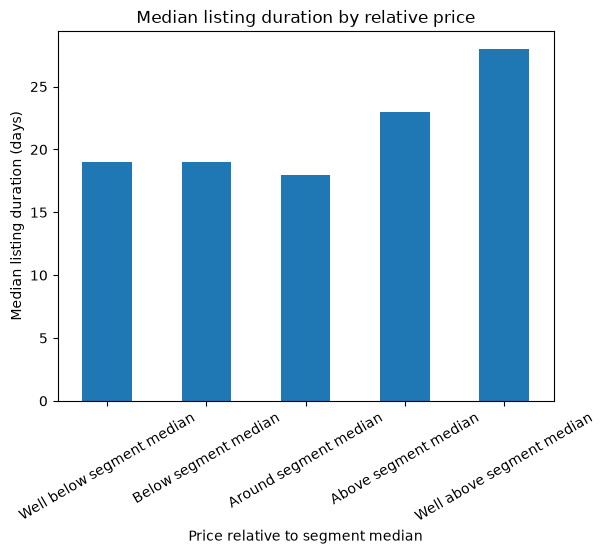

In [95]:
ax = relative_price_duration.plot(
    kind="bar",
    title="Median listing duration by relative price"
)

ax.set_xlabel("Price relative to segment median")
ax.set_ylabel("Median listing duration (days)")
ax.tick_params(axis="x", rotation=30)

### Relative pricing and listing duration

Listings priced around or below the median price per m² of comparable properties show similar median listing durations of 18–19 days.

Listings priced 10–20% above their segment median have a median listing duration of 23 days, approximately 28% longer than listings priced around the segment median (18 days).

The largest difference appears among listings priced more than 20% above their segment median, which remain listed for a median of 28 days — approximately 56% longer than listings priced around the median.

This suggests that pricing above comparable properties is associated with longer listing durations. In particular, listings priced more than 20% above their segment median show a substantially longer observed duration.

This analysis compares asking prices within the same neighborhood and number-of-rooms segment. Listing duration represents observed publication duration and does not necessarily indicate time to sale.

## 8. Which listings appear overpriced compared with similar properties?

In [96]:
df["segment_size"] = (
    df.groupby(["l3", "rooms"])["id"]
      .transform("count")
)

In [97]:
df[
    ["l3", "rooms", "price_per_m2",
     "segment_median_price_m2", "price_vs_segment_pct", "segment_size"]
].head(10)

,l3,rooms,price_per_m2,segment_median_price_m2,price_vs_segment_pct,segment_size
0,Palermo,4.0,4844.559585,3257.387834,48.725293,2582.0
1,Palermo,2.0,2870.967742,3253.968254,-11.770260,4516.0
2,Palermo,2.0,4153.125000,3253.968254,27.632622,4516.0
3,Palermo,3.0,2613.636364,3152.173913,-17.084639,4043.0
4,Palermo,2.0,3000.000000,3253.968254,-7.804878,4516.0
5,Belgrano,4.0,3362.500000,3200.000000,5.078125,2029.0
6,Floresta,3.0,2410.714286,1959.459459,23.029557,211.0
7,Recoleta,1.0,4500.000000,3513.513514,28.076923,808.0
8,Recoleta,2.0,4163.636364,3333.333333,24.909091,1154.0
9,Barrio Norte,3.0,2783.333333,2946.428571,-5.535354,1068.0


In [98]:
df["price_vs_segment_pct"].describe()

count    92175.000000
mean         4.674332
std        124.607083
min        -99.918559
25%        -12.888889
50%          0.000000
75%         14.610312
max      22830.247740
Name: price_vs_segment_pct, dtype: float64

In [99]:
iqr_relative_price = 14.610312 - (-12.888889)

In [100]:
q1 = df["price_vs_segment_pct"].quantile(0.25)
q3 = df["price_vs_segment_pct"].quantile(0.75)

iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr

print(q1)
print(q3)
print(upper_limit)

-12.888888888888886
14.610312425113495
55.859114396117064


To identify listings that may warrant a pricing review, each property's asking price per m² is compared with the median price per m² of listings in the same neighborhood and with the same number of rooms.

Using the IQR method, listings priced more than approximately 55.9% above their segment median are flagged as unusually high-priced.

Only segments with at least 100 comparable listings are considered to reduce the influence of small sample sizes.

These listings are not necessarily overpriced, as differences in condition, amenities, exact location, or other property characteristics may justify a higher asking price.

In [101]:
high_price_listings = df[
    (df["price_vs_segment_pct"] > upper_limit) &
    (df["segment_size"] >= 100)
].copy()

In [102]:
high_price_listings.shape

(3386, 31)

In [103]:
high_price_listings[
    [
        "l3",
        "rooms",
        "price",
        "surface_total",
        "price_per_m2",
        "segment_median_price_m2",
        "price_vs_segment_pct",
        "segment_size"
    ]
].sort_values(
    "price_vs_segment_pct",
    ascending=False
).head(10)

,l3,rooms,price,surface_total,price_per_m2,segment_median_price_m2,price_vs_segment_pct,segment_size
10905,Palermo,1.0,32434232.0,43.0,754284.465116,3289.473684,22830.247740,3144.0
80266,San Nicolás,1.0,10082032.0,31.0,325226.838710,2552.777778,12640.115553,302.0
93962,Caballito,1.0,9477000.0,41.0,231146.341463,2720.655738,8395.979049,1060.0
60768,Caballito,1.0,9477000.0,41.0,231146.341463,2720.655738,8395.979049,1060.0
70442,Caballito,1.0,9477000.0,41.0,231146.341463,2720.655738,8395.979049,1060.0
84673,Caballito,1.0,9477000.0,41.0,231146.341463,2720.655738,8395.979049,1060.0
31071,Caballito,1.0,9477000.0,41.0,231146.341463,2720.655738,8395.979049,1060.0
46254,Caballito,1.0,8748000.0,41.0,213365.853659,2720.655738,7742.442199,1060.0
18399,Caballito,1.0,7897000.0,41.0,192609.756098,2720.655738,6979.534299,1060.0
24261,Caballito,1.0,7897000.0,41.0,192609.756098,2720.655738,6979.534299,1060.0


In [104]:
df["price_per_m2"].quantile([0.95, 0.99, 0.995, 0.999])

0.950     4787.234043
0.990     6865.674627
0.995     7602.339181
0.999    12875.938824
Name: price_per_m2, dtype: float64

In [105]:
print("Above 10k:", (df["price_per_m2"] > 10000).sum())
print("Above 15k:", (df["price_per_m2"] > 15000).sum())
print("Above 20k:", (df["price_per_m2"] > 20000).sum())
print("Above 50k:", (df["price_per_m2"] > 50000).sum())
print("Above 100k:", (df["price_per_m2"] > 100000).sum())

Above 10k: 169
Above 15k: 46
Above 20k: 32
Above 50k: 16
Above 100k: 14


In [106]:
extreme_price_m2 = df[
    df["price_per_m2"] > 20000
]

extreme_price_m2[
    [
        "l3",
        "rooms",
        "price",
        "surface_total",
        "price_per_m2",
        "title"
    ]
].sort_values(
    "price_per_m2",
    ascending=False
)

,l3,rooms,price,surface_total,price_per_m2,title
10905,Palermo,1.0,32434232.0,43.0,754284.465116,Venta Departamento en Palermo Capital Federal ...
80266,San Nicolás,1.0,10082032.0,31.0,325226.838710,Departamento - San Nicolas
93962,Caballito,1.0,9477000.0,41.0,231146.341463,Departamento de 1 ambiente en Venta en Caballito
84673,Caballito,1.0,9477000.0,41.0,231146.341463,Departamento de 1 ambiente en Venta en Caballito
70442,Caballito,1.0,9477000.0,41.0,231146.341463,Departamento de 1 ambiente en Venta en Caballito
31071,Caballito,1.0,9477000.0,41.0,231146.341463,Departamento de 1 ambiente en Venta en Caballito
60768,Caballito,1.0,9477000.0,41.0,231146.341463,Departamento de 1 ambiente en Venta en Caballito
46254,Caballito,1.0,8748000.0,41.0,213365.853659,Departamento de 1 ambiente en Venta en Caballito
10132,Caballito,1.0,7897000.0,41.0,192609.756098,Departamento de 1 ambiente en Venta en Caballito
18399,Caballito,1.0,7897000.0,41.0,192609.756098,Departamento de 1 ambiente en Venta en Caballito


In [107]:
pricing_df = df[
    df["price_per_m2"] <= 20000
].copy()

In [108]:
print(df.shape)
print(pricing_df.shape)

(96735, 31)
(96703, 31)


### Additional data quality check

During the pricing analysis, 32 listings showed extremely high price-per-m² values above USD 20,000/m².

Manual inspection suggested that several of these observations contained likely data quality issues in either the asking price or total surface area. For example, some listings showed multimillion-dollar asking prices for small apartments, while others contained surface values inconsistent with the property description.

These 32 observations (approximately 0.03% of the analytical dataset) were excluded from the pricing analysis. The USD 20,000/m² threshold is used as a conservative analytical rule rather than as a strict definition of an impossible market price.

In [109]:
pricing_df["segment_median_price_m2"] = (
    pricing_df.groupby(["l3", "rooms"])["price_per_m2"]
    .transform("median")
)

pricing_df["price_vs_segment_pct"] = (
    (pricing_df["price_per_m2"] - pricing_df["segment_median_price_m2"])
    / pricing_df["segment_median_price_m2"]
    * 100
)

pricing_df["segment_size"] = (
    pricing_df.groupby(["l3", "rooms"])["id"]
    .transform("count")
)

In [110]:
q1 = pricing_df["price_vs_segment_pct"].quantile(0.25)
q3 = pricing_df["price_vs_segment_pct"].quantile(0.75)

iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr

print(upper_limit)

55.818837771649285


In [111]:
pricing_review_candidates = pricing_df[
    (pricing_df["price_vs_segment_pct"] > upper_limit) &
    (pricing_df["segment_size"] >= 100)
].copy()

In [112]:
pricing_review_candidates.shape

(3362, 31)

In [113]:
pricing_review_candidates[
    [
        "l3",
        "rooms",
        "price",
        "surface_total",
        "price_per_m2",
        "segment_median_price_m2",
        "price_vs_segment_pct",
        "segment_size"
    ]
].sort_values(
    "price_vs_segment_pct",
    ascending=False
).head(10)

,l3,rooms,price,surface_total,price_per_m2,segment_median_price_m2,price_vs_segment_pct,segment_size
55275,Once,4.0,379000.0,19.0,19947.368421,1881.720430,960.060150,175.0
55276,Once,4.0,379000.0,19.0,19947.368421,1881.720430,960.060150,175.0
55277,Once,4.0,379000.0,19.0,19947.368421,1881.720430,960.060150,175.0
52674,Parque Chacabuco,2.0,161900.0,11.0,14718.181818,1985.294118,641.360269,325.0
52056,Almagro,1.0,1111111.0,64.0,17361.109375,2670.000000,550.228816,1655.0
40446,Caballito,3.0,322000.0,20.0,16100.000000,2533.333333,535.526316,1879.0
63829,Palermo,2.0,260000.0,15.0,17333.333333,3253.968254,432.682927,4515.0
31023,Palermo,5.0,8000000.0,410.0,19512.195122,3720.930233,424.390244,659.0
30679,Palermo,4.0,4400007.0,270.0,16296.322222,3257.387834,400.288054,2582.0
30685,Palermo,4.0,4400007.0,270.0,16296.322222,3257.387834,400.288054,2582.0


In [114]:
pricing_review_candidates[
    [
        "id",
        "start_date",
        "l3",
        "rooms",
        "price",
        "surface_total",
        "title"
    ]
].sort_values(
    ["l3", "price", "surface_total"]
).head(20)

,id,start_date,l3,rooms,price,surface_total,title
59258,l70T3s+0V9MJq7A1bRwwzA==,2019-04-23,Abasto,1.0,100000.0,25.0,DEPARTAMENTO EN VENTA
81140,oeP5n0OOoeYqczmrW6EgTg==,2019-07-24,Abasto,1.0,114700.0,27.0,Departamento amoblado con cochera - con o sin ...
54498,P6AMUK71Fy7QFshE8F9CzQ==,2019-04-11,Abasto,1.0,114900.0,27.0,Departamento amoblado con cochera - con o sin ...
4579,hvsBYilPpCiArDDXDEFcwg==,2019-08-04,Abasto,1.0,115000.0,27.0,MONOAMBIENTE EN ABASTO EDIFICIO CON AMENITIES
85683,/1WBCRg5sSkMPL2fSRM87g==,2019-06-01,Abasto,1.0,120000.0,31.0,EXCELENTE MONOAMBIENTE DIVISIBLE CON AMENITIES
96306,SSJgyJCigGY/MhH+U0IU+g==,2020-02-20,Abasto,2.0,170000.0,44.0,VENTA - ESPECTACULAR 2 AMBIENTES CON COCHERA E...
73935,1Tlkq+Xd6uIchJ6596FvFA==,2019-08-20,Abasto,2.0,180000.0,44.0,VENTA - ESPECTACULAR 2 AMBIENTES CON COCHERA E...
78974,rD8WUOQko5bHtBUbnAjxVA==,2019-08-01,Abasto,3.0,245000.0,66.0,REED vende excelente departamento 3 ambientes ...
41768,wQ+EIgPHnRGzKJ1l5RWeHw==,2019-03-19,Abasto,3.0,250000.0,70.0,Departamento - Abasto
16378,MFmWWFc099yc+kGb3p+YNg==,2019-03-10,Abasto,3.0,259000.0,70.0,ESPECTACULAR TORRE DEPTO 3 AMB 2 BAÑOS COMP...


In [115]:
pricing_review_candidates.duplicated(
    subset=[
        "l3",
        "rooms",
        "price",
        "surface_total",
        "title"
    ],
    keep=False
).sum()

np.int64(1095)

In [116]:
pricing_review_candidates.duplicated(
    subset=[
        "lat",
        "lon",
        "rooms",
        "price",
        "surface_total",
        "title"
    ],
    keep=False
).sum()

np.int64(1106)

In [117]:
reliable_pricing_df = pricing_df[
    pricing_df["segment_size"] >= 100
]

candidate_pct = (
    len(pricing_review_candidates)
    / len(reliable_pricing_df)
    * 100
)

candidate_pct

3.86458991896086

### Potential pricing review candidates

After excluding extreme price-per-m² observations likely affected by data quality issues, listings were compared with properties in the same neighborhood and with the same number of rooms.

Using the IQR method, listings priced more than 55.8% above their segment median were flagged for pricing review. Only segments containing at least 100 comparable listings were considered.

A total of 3,362 listings met these criteria, representing approximately 3.9% of listings in sufficiently large comparison segments.

These listings should not automatically be considered overpriced. The analysis does not account for characteristics such as property condition, floor, amenities, exact location, views, terraces, parking spaces, or other features that may justify a higher asking price. Instead, the flag can be used to identify listings that may warrant further pricing review.

## 9. Key findings and business recommendations

In [118]:
segment_summary = (
    pricing_df.groupby(["l3", "rooms"])
    .agg(
        listings=("id", "count"),
        median_price_m2=("price_per_m2", "median"),
        median_price=("price", "median"),
        median_duration=("listing_duration_days", "median")
    )
    .reset_index()
)

segment_summary.head(10)

,l3,rooms,listings,median_price_m2,median_price,median_duration
0,Abasto,1.0,164,2353.889943,94000.0,15.0
1,Abasto,2.0,114,2372.093023,102000.0,14.5
2,Abasto,3.0,103,2243.243243,175000.0,16.0
3,Abasto,4.0,78,2538.461538,235000.0,14.0
4,Abasto,5.0,27,2275.862069,330000.0,14.0
5,Agronomía,1.0,49,2611.111111,94800.0,17.0
6,Agronomía,2.0,39,2340.425532,124088.0,16.0
7,Agronomía,3.0,38,2327.688172,164999.0,53.0
8,Agronomía,4.0,15,2311.688312,290000.0,25.5
9,Agronomía,5.0,2,3280.952381,344500.0,37.0


In [119]:
reliable_segments = segment_summary[
    segment_summary["listings"] >= 100
].copy()

In [120]:
reliable_segments.sort_values(
    ["median_duration", "listings"],
    ascending=[True, False]
).head(15)

,l3,rooms,listings,median_price_m2,median_price,median_duration
154,Liniers,3.0,212,2052.272727,132500.0,11.0
11,Almagro,2.0,2260,2500.000000,115000.0,14.0
10,Almagro,1.0,1655,2670.000000,97000.0,14.0
13,Almagro,4.0,1420,2326.388889,230000.0,14.0
106,Colegiales,1.0,717,2412.500000,77100.0,14.0
213,Parque Centenario,3.0,441,2444.444444,175000.0,14.0
214,Parque Centenario,4.0,302,2272.727273,268000.0,14.0
216,Parque Chacabuco,1.0,264,2440.056561,113537.0,14.0
212,Parque Centenario,2.0,237,2297.297297,103000.0,14.0
14,Almagro,5.0,136,2268.965517,329000.0,14.0


In [121]:
segment_supply = (
    base_df.groupby(["l3", "rooms"])
    .agg(
        total_listings=("id", "count")
    )
    .reset_index()
)

segment_supply.head()

,l3,rooms,total_listings
0,Abasto,1.0,184
1,Abasto,2.0,142
2,Abasto,3.0,118
3,Abasto,4.0,81
4,Abasto,5.0,27


In [122]:
segment_analysis = segment_summary.merge(
    segment_supply,
    on=["l3", "rooms"],
    how="left"
)

In [123]:
segment_analysis.head()

,l3,rooms,listings,median_price_m2,median_price,median_duration,total_listings
0,Abasto,1.0,164,2353.889943,94000.0,15.0,184
1,Abasto,2.0,114,2372.093023,102000.0,14.5,142
2,Abasto,3.0,103,2243.243243,175000.0,16.0,118
3,Abasto,4.0,78,2538.461538,235000.0,14.0,81
4,Abasto,5.0,27,2275.862069,330000.0,14.0,27


In [124]:
attractive_segments = segment_analysis[
    (segment_analysis["total_listings"] >= 500) &
    (segment_analysis["median_duration"] <= 20)
]

In [125]:
attractive_segments.sort_values(
    "total_listings",
    ascending=False
).head(15)

,l3,rooms,listings,median_price_m2,median_price,median_duration,total_listings
195,Palermo,2.0,4515,3253.968254,164000.0,15.0,4967
196,Palermo,3.0,4043,3152.173913,250000.0,15.0,4410
194,Palermo,1.0,3143,3289.473684,120000.0,17.0,3605
12,Almagro,3.0,2353,2462.686567,175000.0,15.0,2641
11,Almagro,2.0,2260,2500.000000,115000.0,14.0,2556
334,Villa Crespo,2.0,2319,2571.428571,112000.0,15.0,2539
335,Villa Crespo,3.0,1728,2365.079365,160000.0,15.0,1987
10,Almagro,1.0,1655,2670.000000,97000.0,14.0,1845
333,Villa Crespo,1.0,1453,2658.536585,96672.0,15.0,1641
13,Almagro,4.0,1420,2326.388889,230000.0,14.0,1557


## Attractive segments for acquisition

To identify potentially attractive segments for property acquisition, segments with at least 500 listings and a median observed listing duration of 20 days or less were selected.

Palermo stands out due to its combination of high listing volume and relatively short observed duration. Two-room apartments represent the largest qualifying segment, with 4,967 listings and a median duration of 15 days, followed by three-room apartments with 4,410 listings and the same median duration.

Almagro and Villa Crespo also show attractive high-volume segments, particularly two-room apartments, with median observed durations of 14 and 15 days respectively.

These results suggest that Palermo 2- and 3-room apartments could be strong acquisition priorities for an agency seeking high-volume segments with relatively fast listing turnover. Almagro and Villa Crespo, especially 2-room apartments, may represent additional opportunities.

Listing duration represents observed publication duration and should not be interpreted as confirmed time to sale.

In [126]:
plot_segments = segment_analysis[
    segment_analysis["total_listings"] >= 500
]

Text(0, 0.5, 'Median listing duration (days)')

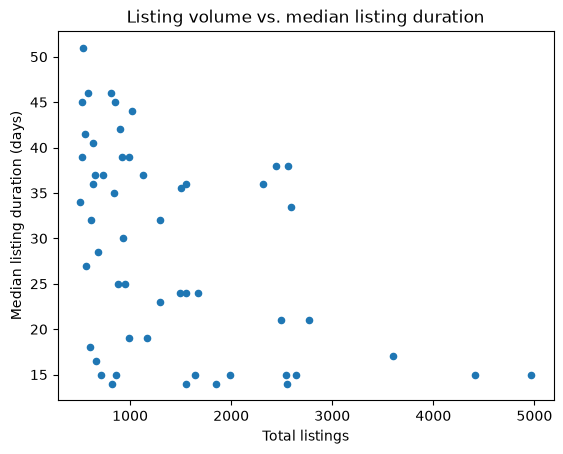

In [132]:
ax = plot_segments.plot(
    kind="scatter",
    x="total_listings",
    y="median_duration",
    title="Listing volume vs. median listing duration"
)

ax.set_xlabel("Total listings")
ax.set_ylabel("Median listing duration (days)")

In [128]:
for _, row in attractive_segments.iterrows():
    ax.annotate(
        f"{row['l3']} - {int(row['rooms'])} rooms",
        (row["total_listings"], row["median_duration"])
    )

In [130]:
segments_to_label = attractive_segments[
    (
        (attractive_segments["l3"] == "Palermo") &
        (attractive_segments["rooms"].isin([1, 2, 3]))
    )
    |
    (
        (attractive_segments["l3"] == "Almagro") &
        (attractive_segments["rooms"] == 2)
    )
    |
    (
        (attractive_segments["l3"] == "Villa Crespo") &
        (attractive_segments["rooms"] == 2)
    )
    |
    (
        (attractive_segments["l3"] == "Barrio Norte") &
        (attractive_segments["rooms"] == 3)
    )
]

In [131]:
for _, row in segments_to_label.iterrows():
    ax.annotate(
        f"{row['l3']} - {int(row['rooms'])} rooms",
        (row["total_listings"], row["median_duration"])
    )

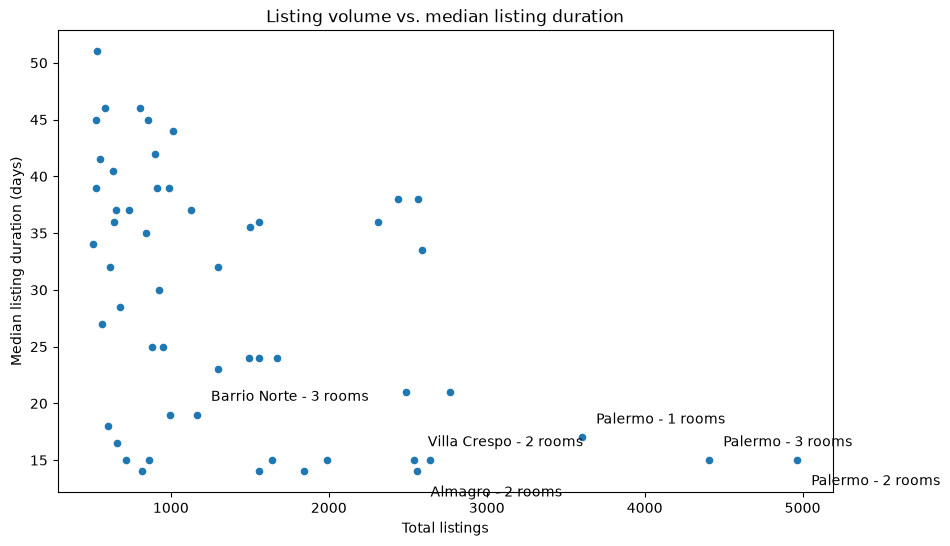

In [135]:
plot_segments = segment_analysis[
    segment_analysis["total_listings"] >= 500
]

segments_to_label = attractive_segments[
    (
        (attractive_segments["l3"] == "Palermo") &
        (attractive_segments["rooms"].isin([1, 2, 3]))
    )
    |
    (
        (attractive_segments["l3"] == "Almagro") &
        (attractive_segments["rooms"] == 2)
    )
    |
    (
        (attractive_segments["l3"] == "Villa Crespo") &
        (attractive_segments["rooms"] == 2)
    )
    |
    (
        (attractive_segments["l3"] == "Barrio Norte") &
        (attractive_segments["rooms"] == 3)
    )
]

ax = plot_segments.plot(
    kind="scatter",
    x="total_listings",
    y="median_duration",
    title="Listing volume vs. median listing duration",
    figsize=(10, 6)
)

ax.set_xlabel("Total listings")
ax.set_ylabel("Median listing duration (days)")

label_offsets = {
    ("Palermo", 1): (10, 10),
    ("Palermo", 2): (10, -18),
    ("Palermo", 3): (10, 10),
    ("Almagro", 2): (10, -18),
    ("Villa Crespo", 2): (10, 10),
    ("Barrio Norte", 3): (10, 10)
}

for _, row in segments_to_label.iterrows():
    key = (row["l3"], int(row["rooms"]))
    offset = label_offsets[key]

    ax.annotate(
        f"{row['l3']} - {int(row['rooms'])} rooms",
        (row["total_listings"], row["median_duration"]),
        xytext=offset,
        textcoords="offset points"
    )

## 10. Key findings and business recommendations

### Key findings

- Apartment supply is highly concentrated in a few neighborhoods, with Palermo representing approximately 15% of CABA apartment listings.
- Smaller apartments tend to command higher asking prices per m². This pattern remains visible when comparing 1-, 2-, and 3-room apartments within the same high-supply neighborhoods.
- Listing duration varies substantially across neighborhoods and segments. High-volume segments in Palermo, Almagro, and Villa Crespo show relatively short observed listing durations.
- Total asking price is not linearly associated with listing duration. Properties between USD 150k and USD 300k show the shortest median observed durations, while listings above USD 500k remain listed longer.
- Relative pricing shows a clearer relationship with listing duration. Listings priced more than 20% above comparable properties remain listed for a median of 28 days, approximately 56% longer than listings priced around their segment median.
- Approximately 3.9% of listings in sufficiently large comparison segments were flagged for pricing review because their asking price per m² was more than 55.8% above their segment median.

### Business recommendations

A real estate agency could prioritize acquisition efforts toward high-volume segments with relatively short observed listing durations, particularly 2- and 3-room apartments in Palermo and 2-room apartments in Almagro and Villa Crespo.

Pricing recommendations should consider comparable properties within the same neighborhood and room category rather than relying only on broad CABA averages.

Listings priced substantially above comparable properties should receive additional pricing review, particularly when the asking price exceeds the segment median by more than 20%, as these listings are associated with longer observed publication durations.

## Limitations

- The dataset contains property listings rather than confirmed real estate transactions. Asking prices should therefore not be interpreted as final sale prices.

- Listing end dates do not confirm that a property was sold. For this reason, listing duration represents observed publication duration rather than time to sale.

- Approximately 25% of the analyzed listings do not have a usable end date, so listing-duration analyses are based only on listings with known end dates.

- The dataset represents a historical period and should not be interpreted as a description of the current Buenos Aires real estate market.

- Data quality issues were identified in variables such as price and total surface area. Extremely implausible price-per-m² observations were excluded from pricing analyses.

- Listings with different IDs sometimes share identical or highly similar property characteristics. Therefore, a unique listing ID should not necessarily be interpreted as a unique physical property.

- Pricing comparisons account for neighborhood and number of rooms, but other relevant characteristics such as exact location, property condition, floor, amenities, parking, views, terraces, and building quality are not controlled for.

- The relationships identified in this analysis are descriptive and should not be interpreted as causal.